In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
daydf = pd.read_csv("../data/raw/day.csv")
hourdf = pd.read_csv("../data/raw/hour.csv")


In [ ]:
print(daydf.head())
print(hourdf.head())

In [13]:
print(daydf.shape)
print(hourdf.shape)

(731, 16)
(17379, 17)


In [11]:
print(daydf.describe())
print(hourdf.describe())

          instant      season          yr        mnth     holiday     weekday  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean   366.000000    2.496580    0.500684    6.519836    0.028728    2.997264   
std    211.165812    1.110807    0.500342    3.451913    0.167155    2.004787   
min      1.000000    1.000000    0.000000    1.000000    0.000000    0.000000   
25%    183.500000    2.000000    0.000000    4.000000    0.000000    1.000000   
50%    366.000000    3.000000    1.000000    7.000000    0.000000    3.000000   
75%    548.500000    3.000000    1.000000   10.000000    0.000000    5.000000   
max    731.000000    4.000000    1.000000   12.000000    1.000000    6.000000   

       workingday  weathersit        temp       atemp         hum   windspeed  \
count  731.000000  731.000000  731.000000  731.000000  731.000000  731.000000   
mean     0.683995    1.395349    0.495385    0.474354    0.627894    0.190486   
std      0.465233    0.5448

In [14]:
daydf.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [20]:
daydf['dteday'] = pd.to_datetime(daydf['dteday'])

In [17]:
hourdf.info()

<class 'pandas.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  str    
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), str(1)
memory usage: 2.3 MB


In [21]:
hourdf['dteday'] = pd.to_datetime(hourdf['dteday'])

-transfer datatype of dteday from string to datetime initially

In [5]:
daydf.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [6]:
hourdf.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
print(daydf.duplicated().sum())

0


In [9]:
print(hourdf.duplicated().sum())

0


-No cleaning action required because there is no duplicate or data missing

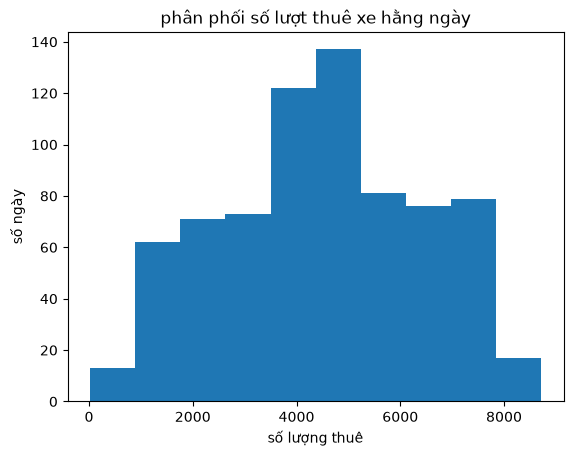

In [28]:
plt.hist(daydf['cnt'])
plt.title("phân phối số lượt thuê xe hằng ngày")
plt.xlabel("số lượng thuê")
plt.ylabel("số ngày")
plt.show()


-Most rental count lay between ~ 3500-5500
-approxiamtely bell shaped
-extremely low and high rental count occur infrequently

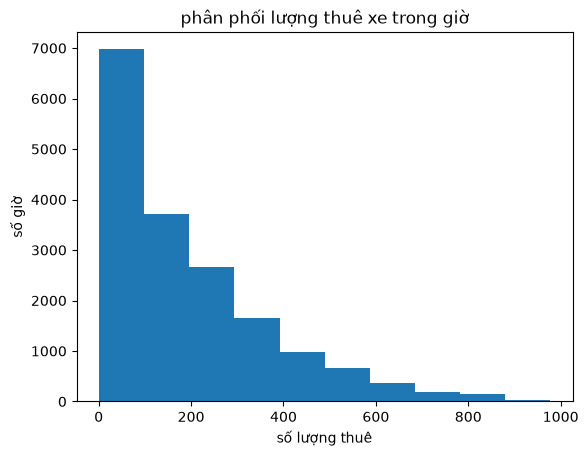

In [29]:
plt.hist(hourdf['cnt'])
plt.title("phân phối lượng thuê xe trong giờ")
plt.xlabel("số lượng thuê")
plt.ylabel("số giờ")
plt.show()



-Most hours have fewer than 100 bike rentals
-Higher rental counts occur, lower number of hours

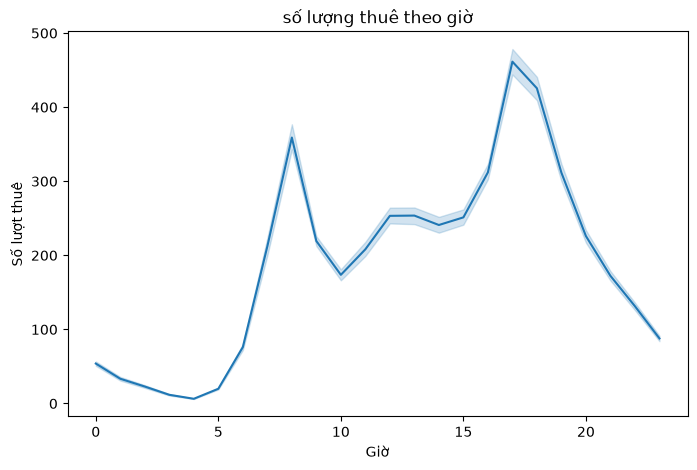

In [34]:
plt.figure(figsize=(8,5))
sns.lineplot(data=hourdf, x='hr', y='cnt')
plt.title("số lượng thuê theo giờ")
plt.xlabel("Giờ")
plt.ylabel("Số lượt thuê")
plt.show()


## comment
-first peak occurs around 8AM, while the higher second one occurs around 17PM
-rental count lowest recording is from 0AM-5AM

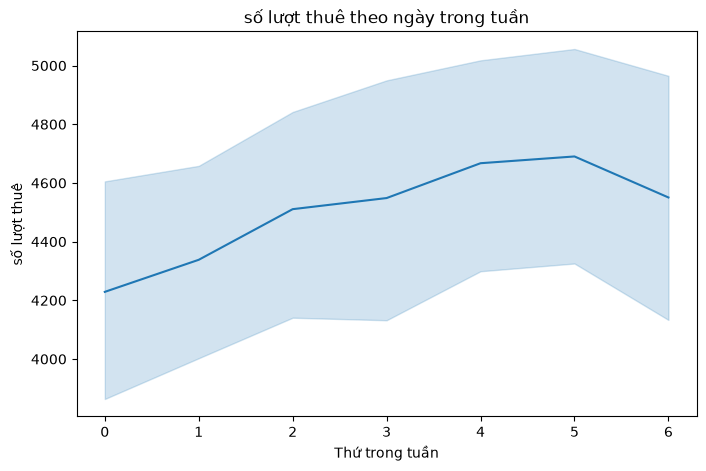

In [35]:
plt.figure(figsize=(8,5))
sns.lineplot(data=daydf, x = 'weekday', y='cnt')
plt.title("số lượt thuê theo ngày trong tuần")
plt.xlabel("Thứ trong tuần")
plt.ylabel("số lượt thuê")
plt.show()

## comment
-the chart doesn'n have big fluctuation
-rental count increases from monday to friday, decrease in saturday and sunday

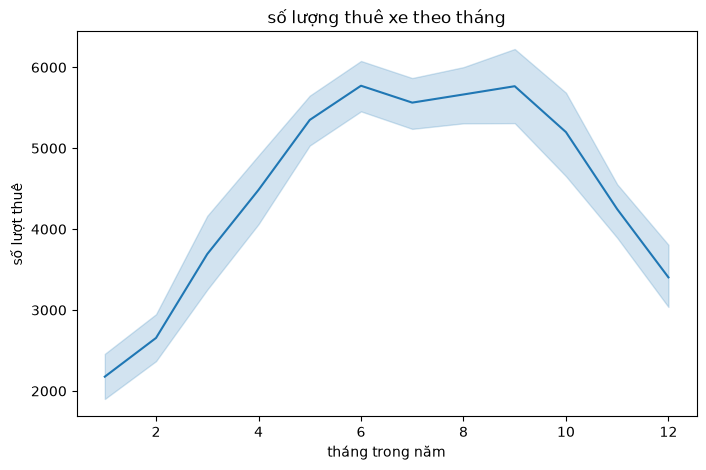

In [36]:
plt.figure(figsize=(8,5))
sns.lineplot(data=daydf, x = 'mnth', y='cnt')
plt.title("số lượng thuê xe theo tháng")
plt.xlabel("tháng trong năm")
plt.ylabel("số lượt thuê")
plt.show()

-first few months of the year have low rental count but increase steadily from january to june
-rental count stays quite stable from june to september and decrease for the rest of the year